In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('../data/merged_macro_cpi_2000_2026.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
display(df.head(3))
print("\nLast 3 rows:")
display(df.tail(3))
print("\nData types:\n", df.dtypes)
print("\nMissing values total:", df.isnull().sum().sum())

Shape: (313, 21)

Columns: ['date', 'exchange_rate', 'oil_price', 'domestic_production', 'crude_oil_export', 'All Items', 'All Items Less Farm Produce', 'All Items Less Farm Produce And Energy', 'Imported Food', 'Food', 'Alcoholic Beverage Tobacco And Kola', 'Clothing And Footwear', 'Housing Water Electricity Gas And Other  Fuel', 'Furnishings And Household Equipment Maintenance', 'Health', 'Transport', 'Communication', 'Recreation And Culture', 'Education', 'Restaurant And Hotels', 'Miscellaneous Goods And Services']

First 3 rows:


,date,exchange_rate,oil_price,domestic_production,crude_oil_export,All Items,All Items Less Farm Produce,All Items Less Farm Produce And Energy,Imported Food,Food,...,Clothing And Footwear,Housing Water Electricity Gas And Other Fuel,Furnishings And Household Equipment Maintenance,Health,Transport,Communication,Recreation And Culture,Education,Restaurant And Hotels,Miscellaneous Goods And Services
0,2/1/2000,100.20,63.85,2.59,2.14,6.8042,7.1634,8.5224,22.8788,5.3230,...,13.8690,5.5024,10.3458,13.3201,8.9416,9.2247,9.0143,7.0856,6.9803,6.0720
1,3/1/2000,100.12,63.85,2.59,2.14,6.8774,7.2892,8.6276,22.8788,5.3572,...,13.7952,5.6488,10.7347,13.2583,8.8861,9.2247,9.1836,7.0856,6.9803,6.1315
2,4/1/2000,99.87,63.85,2.59,2.14,7.0146,7.4265,8.6665,22.8788,5.4561,...,13.9986,5.9005,10.7965,13.2514,8.9113,9.2247,9.0349,7.0856,6.9803,6.1796



Last 3 rows:


,date,exchange_rate,oil_price,domestic_production,crude_oil_export,All Items,All Items Less Farm Produce,All Items Less Farm Produce And Energy,Imported Food,Food,...,Clothing And Footwear,Housing Water Electricity Gas And Other Fuel,Furnishings And Household Equipment Maintenance,Health,Transport,Communication,Recreation And Culture,Education,Restaurant And Hotels,Miscellaneous Goods And Services
310,12/1/2025,1435.7571,65.22,1.44,0.99,131.166592,132.10,132.79,128.72,127.83,...,124.12,131.21,133.62,142.36,133.87,126.48,116.86,128.15,136.19,139.11
311,1/1/2026,1435.7571,68.05,1.46,1.01,127.390000,129.72,130.55,119.96,120.14,...,125.03,131.89,133.59,142.59,132.50,123.62,108.48,128.46,136.08,139.50
312,2/1/2026,1435.7571,72.33,1.31,0.86,129.950000,130.76,131.71,120.74,125.77,...,124.16,131.30,134.67,142.90,132.16,123.69,109.36,128.58,137.61,139.97



Data types:
 date                                                object
exchange_rate                                      float64
oil_price                                          float64
domestic_production                                float64
crude_oil_export                                   float64
All Items                                          float64
All Items Less Farm Produce                        float64
All Items Less Farm Produce And Energy             float64
Imported Food                                      float64
Food                                               float64
Alcoholic Beverage Tobacco And Kola                float64
Clothing And Footwear                              float64
Housing Water Electricity Gas And Other  Fuel      float64
Furnishings And Household Equipment Maintenance    float64
Health                                             float64
Transport                                          float64
Communication                             

In [14]:
# 1. Convert date to datetime and set as index
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')
df = df.set_index('date')
df = df.sort_index()

# 2. Rename columns for easier handling (optional but helpful)
df = df.rename(columns={
    'All Items': 'cpi_all',
    'Food': 'cpi_food',
    'Transport': 'cpi_transport',
    'Clothing And Footwear': 'cpi_clothing',
    'exchange_rate': 'ex_rate',
    'oil_price': 'oil_price'
    # add more if needed
})

# 3. Create MoM % change for targets (this is what we want to forecast)
targets = ['cpi_food', 'cpi_transport', 'cpi_clothing']

for col in targets:
    df[f'{col}_mom'] = df[col].pct_change() * 100

# Also create MoM for All Items (inflation proxy)
df['cpi_all_mom'] = df['cpi_all'].pct_change() * 100

# 4. Check for missing values after pct_change (first row will be NaN)
print("Missing values after MoM calculation:\n", df[targets + [f'{t}_mom' for t in targets] + ['cpi_all_mom']].isnull().sum())

# Drop the very first row if NaN
df = df.dropna(subset=[f'{col}_mom' for col in targets])

print(f"\nFinal dataset shape after cleaning: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")

Missing values after MoM calculation:
 cpi_food             0
cpi_transport        0
cpi_clothing         0
cpi_food_mom         1
cpi_transport_mom    1
cpi_clothing_mom     1
cpi_all_mom          1
dtype: int64

Final dataset shape after cleaning: (312, 24)
Date range: 2000-03-01 00:00:00 to 2026-02-01 00:00:00


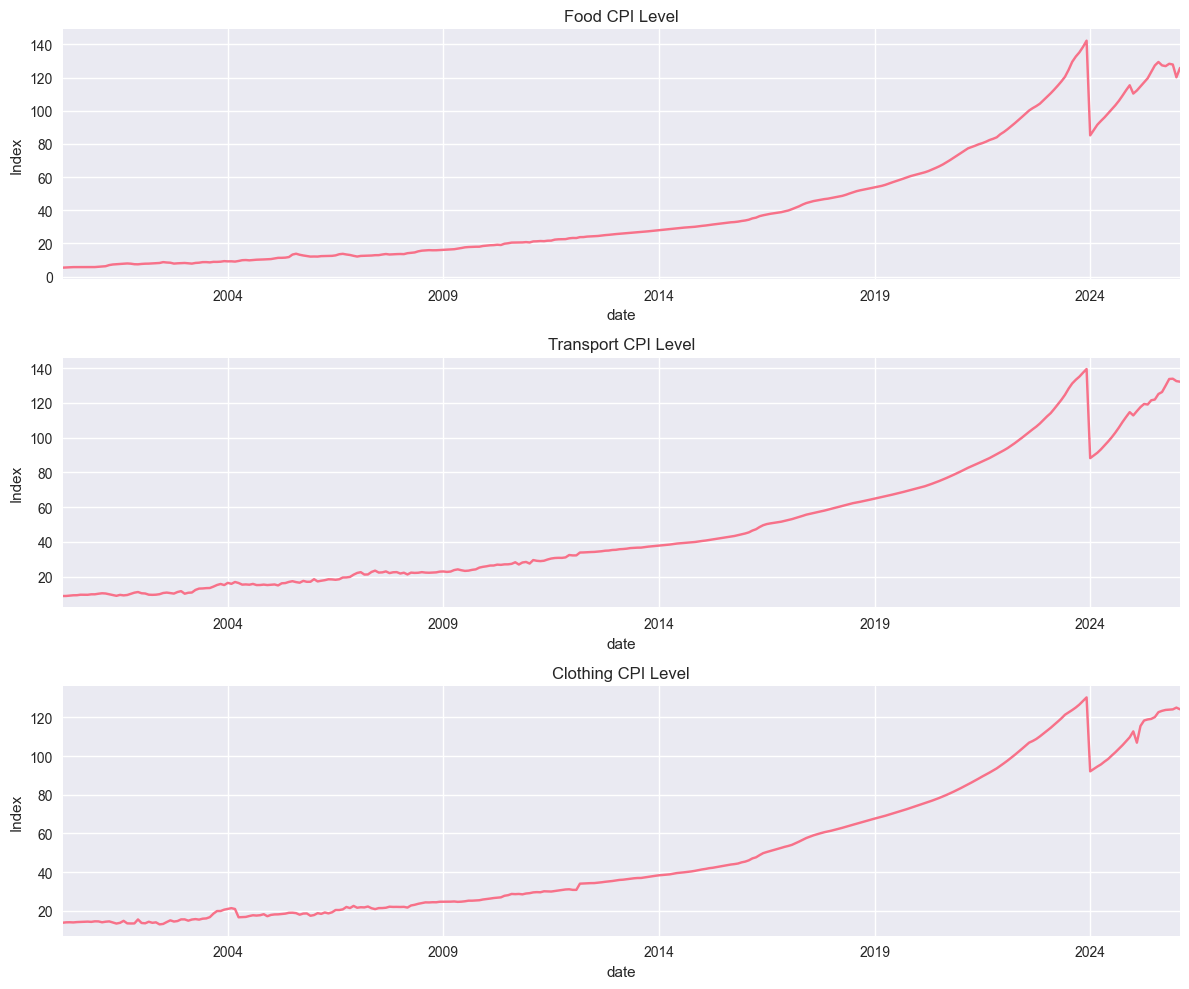

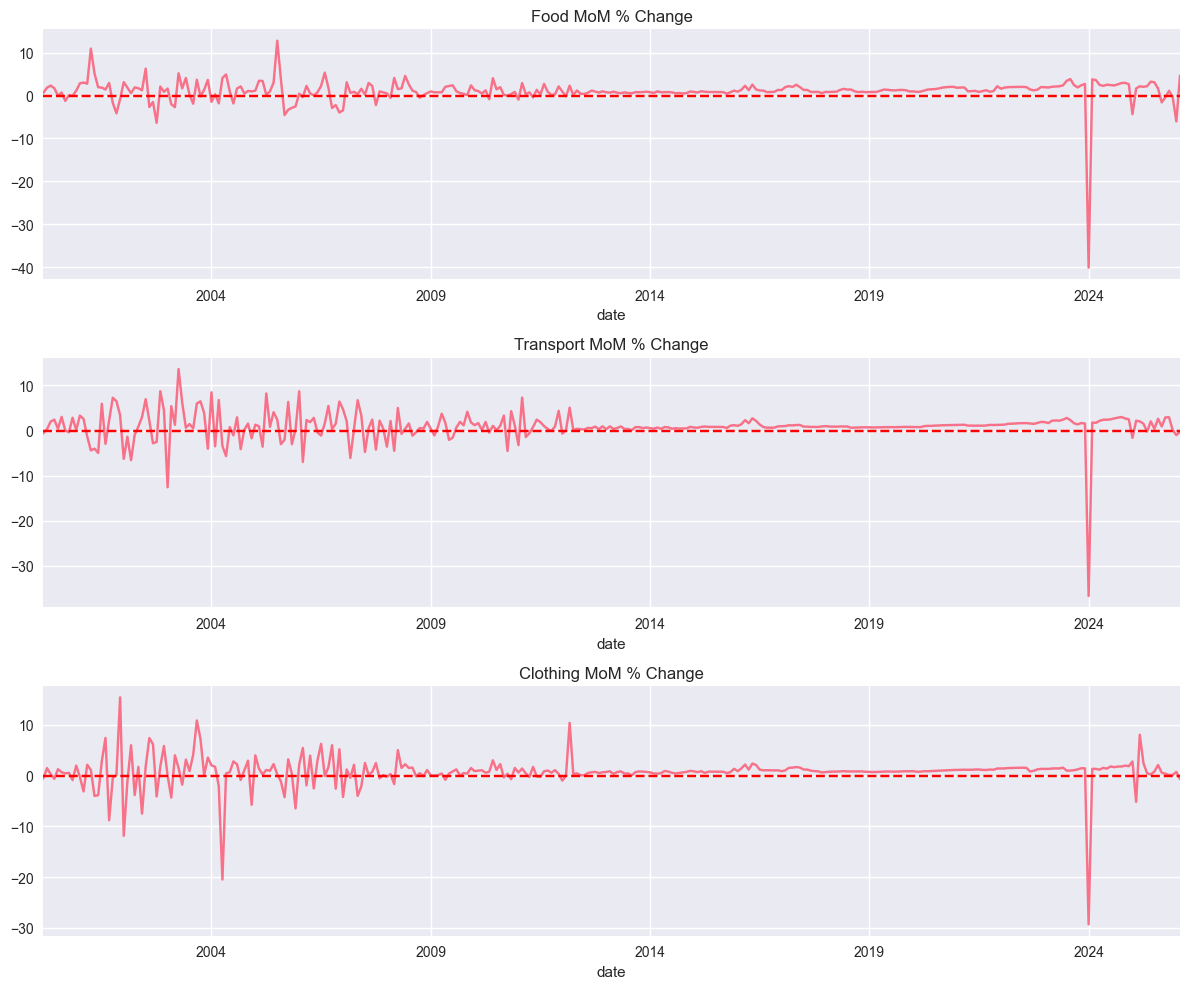

In [15]:
# Plot original CPI levels
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i, col in enumerate(targets):
    df[col].plot(ax=axes[i], title=f'{col.replace("cpi_", "").title()} CPI Level')
    axes[i].set_ylabel('Index')
plt.tight_layout()
plt.savefig('../output/cpi_levels.png')
plt.show()

# Plot MoM % changes (our targets)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
for i, col in enumerate([f'{t}_mom' for t in targets]):
    df[col].plot(ax=axes[i], title=f'{targets[i].replace("cpi_", "").title()} MoM % Change')
    axes[i].axhline(y=0, color='r', linestyle='--')
plt.tight_layout()
plt.savefig('../output/mom_changes.png')
plt.show()

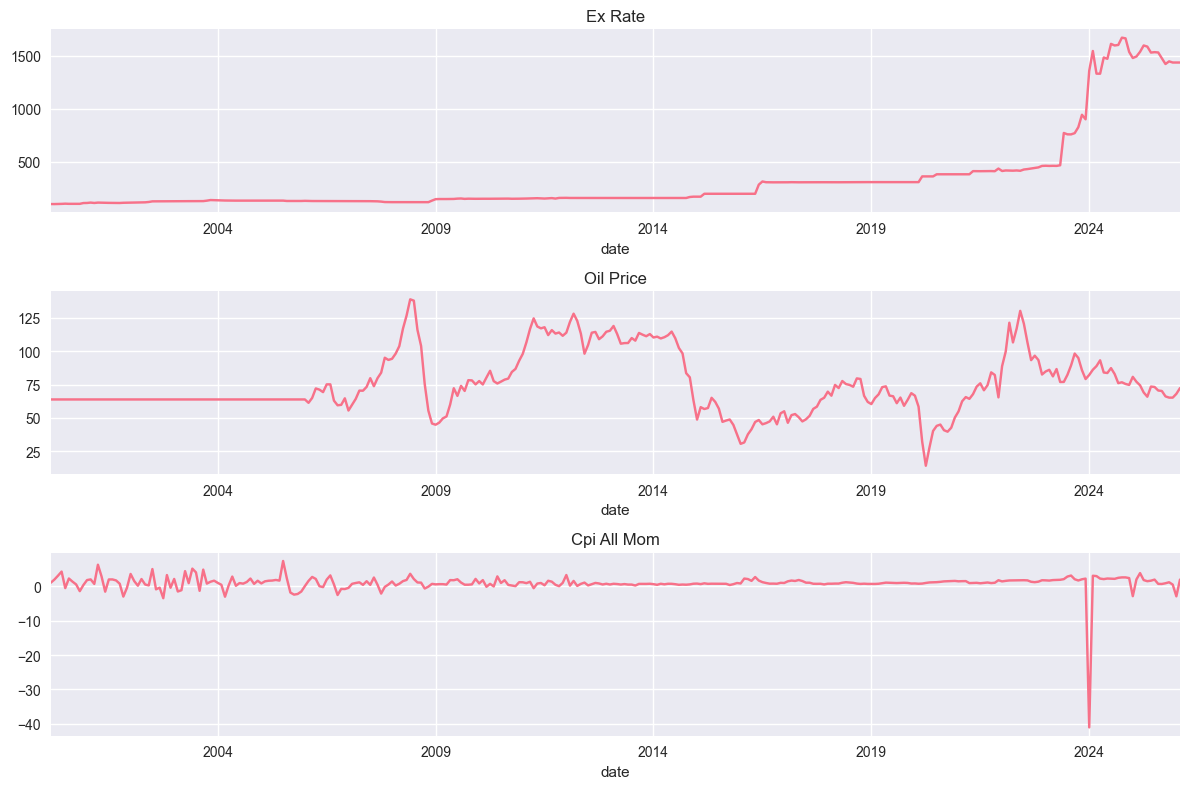

In [16]:
macro_cols = ['ex_rate', 'oil_price', 'cpi_all_mom']
fig, axes = plt.subplots(len(macro_cols), 1, figsize=(12, 8))
for i, col in enumerate(macro_cols):
    df[col].plot(ax=axes[i], title=col.replace('_', ' ').title())
plt.tight_layout()
plt.savefig('../output/macro_variables.png')
plt.show()

Using dataset with shape: (312, 24)


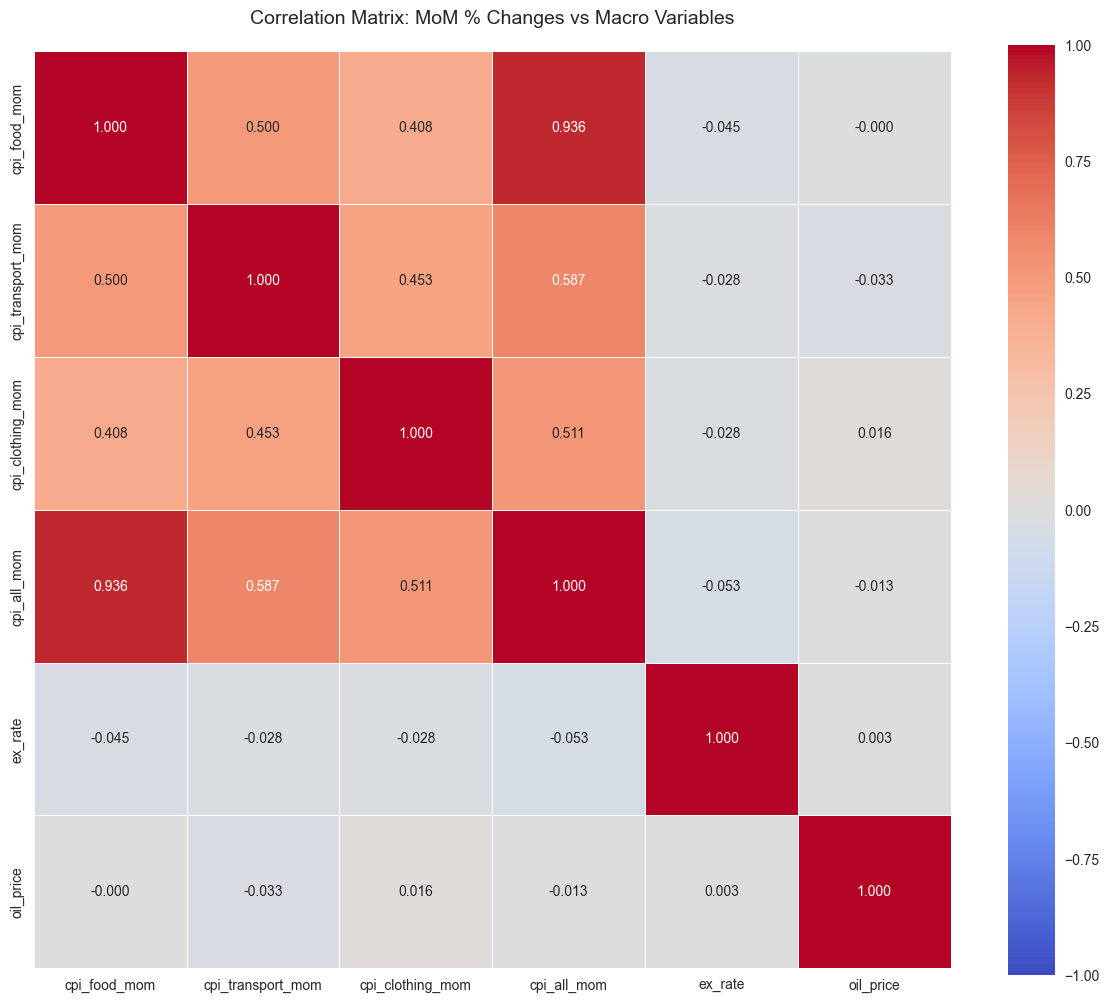


=== Correlation Matrix (rounded to 3 decimals) ===
                   cpi_food_mom  cpi_transport_mom  cpi_clothing_mom  \
cpi_food_mom              1.000              0.500             0.408   
cpi_transport_mom         0.500              1.000             0.453   
cpi_clothing_mom          0.408              0.453             1.000   
cpi_all_mom               0.936              0.587             0.511   
ex_rate                  -0.045             -0.028            -0.028   
oil_price                -0.000             -0.033             0.016   

                   cpi_all_mom  ex_rate  oil_price  
cpi_food_mom             0.936   -0.045     -0.000  
cpi_transport_mom        0.587   -0.028     -0.033  
cpi_clothing_mom         0.511   -0.028      0.016  
cpi_all_mom              1.000   -0.053     -0.013  
ex_rate                 -0.053    1.000      0.003  
oil_price               -0.013    0.003      1.000  


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss

# Make sure df is from the previous cleaning step
print("Using dataset with shape:", df.shape)

# Columns for analysis
target_mom_cols = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom', 'cpi_all_mom']
macro_cols = ['ex_rate', 'oil_price']

analysis_cols = target_mom_cols + macro_cols

# Correlation matrix (Pearson)
corr_matrix = df[analysis_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            center=0, fmt='.3f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: MoM % Changes vs Macro Variables', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../output/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Correlation Matrix (rounded to 3 decimals) ===")
print(corr_matrix.round(3))

In [18]:
# Stationarity test functions
def adf_test(series, title=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'\nADF Test for {title}:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-stationary (Fail to reject null)'
    print(f'Conclusion: {conclusion}')
    return result[1] < 0.05

def kpss_test(series, title=''):
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'\nKPSS Test for {title}:')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    conclusion = 'Stationary' if result[1] > 0.05 else 'Non-stationary (Reject null)'
    print(f'Conclusion: {conclusion}')
    return result[1] > 0.05

print("=== Stationarity Tests ===")
stationary_summary = {}

for col in target_mom_cols + macro_cols:
    print(f"\n--- Testing: {col} ---")
    adf_stat = adf_test(df[col], col)
    kpss_stat = kpss_test(df[col], col)
    stationary_summary[col] = {'ADF': adf_stat, 'KPSS': kpss_stat}

print("\nSummary:")
for col, res in stationary_summary.items():
    print(f"{col}: ADF Stationary = {res['ADF']}, KPSS Stationary = {res['KPSS']}")

=== Stationarity Tests ===

--- Testing: cpi_food_mom ---

ADF Test for cpi_food_mom:
ADF Statistic: -16.8664
p-value: 0.0000
Critical Values:
   1%: -3.4516
   5%: -2.8709
   10%: -2.5717
Conclusion: Stationary

KPSS Test for cpi_food_mom:
KPSS Statistic: 0.0296
p-value: 0.1000
Conclusion: Stationary

--- Testing: cpi_transport_mom ---

ADF Test for cpi_transport_mom:
ADF Statistic: -18.7572
p-value: 0.0000
Critical Values:
   1%: -3.4516
   5%: -2.8709
   10%: -2.5717
Conclusion: Stationary

KPSS Test for cpi_transport_mom:
KPSS Statistic: 0.0237
p-value: 0.1000
Conclusion: Stationary

--- Testing: cpi_clothing_mom ---

ADF Test for cpi_clothing_mom:
ADF Statistic: -8.5026
p-value: 0.0000
Critical Values:
   1%: -3.4520
   5%: -2.8711
   10%: -2.5718
Conclusion: Stationary

KPSS Test for cpi_clothing_mom:
KPSS Statistic: 0.0604
p-value: 0.1000
Conclusion: Stationary

--- Testing: cpi_all_mom ---

ADF Test for cpi_all_mom:
ADF Statistic: -17.8669
p-value: 0.0000
Critical Values:
   1%

Current date range in df: 2000-03-01 00:00:00 to 2026-02-01 00:00:00

Train set: (262, 24) | 2000-03-01 to 2021-12-01
Validation set: (24, 24) | 2022-01-01 to 2023-12-01
Test set: (26, 24) | 2024-01-01 to 2026-02-01


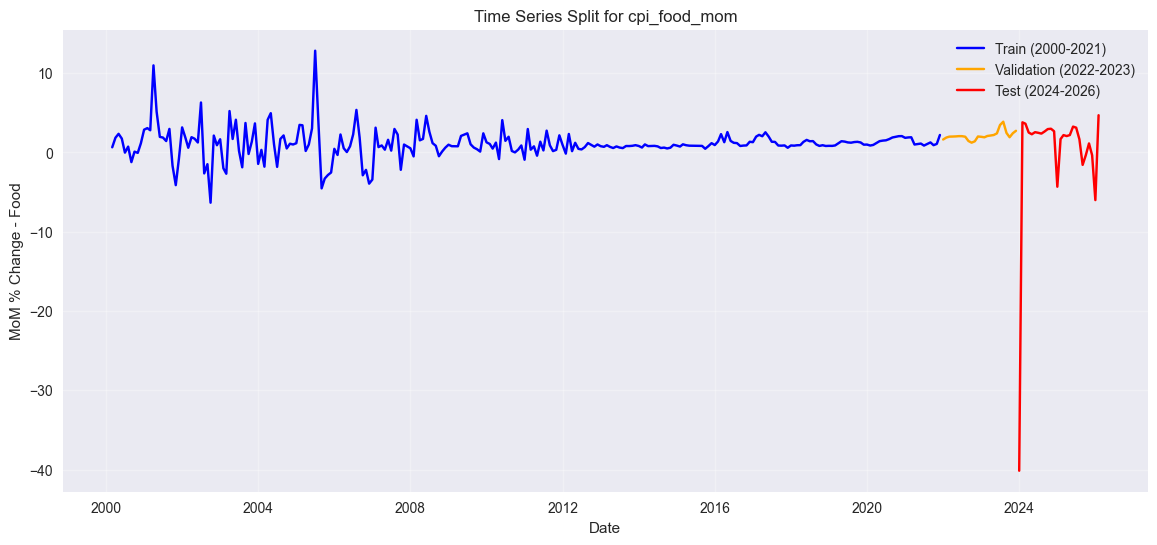


Raw splits saved to data/train_raw.csv, val_raw.csv, test_raw.csv


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure df is the cleaned version with MoM columns
print("Current date range in df:", df.index.min(), "to", df.index.max())

# Define splits as requested
train = df.loc[:'2021-12-31'].copy()
val   = df.loc['2022-01-01':'2023-12-31'].copy()
test  = df.loc['2024-01-01':].copy()

print(f"\nTrain set: {train.shape} | {train.index.min().date()} to {train.index.max().date()}")
print(f"Validation set: {val.shape} | {val.index.min().date()} to {val.index.max().date()}")
print(f"Test set: {test.shape} | {test.index.min().date()} to {test.index.max().date()}")

# Visualize the split
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['cpi_food_mom'], label='Train (2000-2021)', color='blue')
plt.plot(val.index, val['cpi_food_mom'], label='Validation (2022-2023)', color='orange')
plt.plot(test.index, test['cpi_food_mom'], label='Test (2024-2026)', color='red')
plt.title('Time Series Split for cpi_food_mom')
plt.xlabel('Date')
plt.ylabel('MoM % Change - Food')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../output/data_split_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# Save raw splits
train.to_csv('../data/train_raw.csv')
val.to_csv('../data/val_raw.csv')
test.to_csv('../data/test_raw.csv')

print("\nRaw splits saved to data/train_raw.csv, val_raw.csv, test_raw.csv")

In [20]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

def create_features_full(df):
    """Feature engineering on the FULL cleaned dataset before splitting"""
    df_fe = df.copy()
    
    targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']
    macros = ['ex_rate', 'oil_price', 'cpi_all_mom']
    all_predictors = targets + macros
    
    # 1. Lags - Reduced to 1-6 months to preserve more data
    for col in all_predictors:
        for lag in range(1, 7):          # Changed from 12 to 6
            df_fe[f'{col}_lag{lag}'] = df_fe[col].shift(lag)
    
    # 2. Differences and % changes for exogenous
    for col in ['ex_rate', 'oil_price', 'cpi_all_mom']:
        df_fe[f'{col}_diff'] = df_fe[col].diff()
        df_fe[f'{col}_diff_lag1'] = df_fe[f'{col}_diff'].shift(1)
        df_fe[f'{col}_pct_change'] = df_fe[col].pct_change() * 100
    
    # 3. Rolling statistics - Reduced windows
    for col in all_predictors:
        for window in [3, 6]:            # Removed 12
            df_fe[f'{col}_roll_mean_{window}'] = df_fe[col].rolling(window=window).mean()
            df_fe[f'{col}_roll_std_{window}'] = df_fe[col].rolling(window=window).std()
    
    # 4. Seasonal & calendar features
    df_fe['month'] = df_fe.index.month
    df_fe['quarter'] = df_fe.index.quarter
    df_fe['is_year_end'] = (df_fe.index.month == 12).astype(int)
    
    # 5. Economic shock dummies
    df_fe['post_subsidy_removal'] = (df_fe.index >= '2023-06-01').astype(int)
    df_fe['covid_period'] = ((df_fe.index >= '2020-03-01') & (df_fe.index <= '2021-12-31')).astype(int)
    
    # 6. Seasonal Decomposition (on full data for better trend/seasonal)
    try:
        decomp = seasonal_decompose(df_fe['cpi_all_mom'], model='additive', period=12)
        df_fe['cpi_all_trend'] = decomp.trend
        df_fe['cpi_all_seasonal'] = decomp.seasonal
        df_fe['cpi_all_residual'] = decomp.resid
    except Exception as e:
        print("Seasonal decomposition warning:", e)
        df_fe['cpi_all_trend'] = np.nan
        df_fe['cpi_all_seasonal'] = np.nan
        df_fe['cpi_all_residual'] = np.nan
    
    # Drop NaNs (now only early rows are lost)
    df_fe = df_fe.dropna()
    
    print(f"Final shape after full feature engineering: {df_fe.shape}")
    print(f"Date range: {df_fe.index.min().date()} to {df_fe.index.max().date()}")
    
    return df_fe

# ====================== RUN THIS ======================

# Assuming 'df' is your cleaned dataframe with MoM columns
full_fe = create_features_full(df)

# Now split the engineered dataframe
train_fe = full_fe.loc[:'2021-12-31'].copy()
val_fe   = full_fe.loc['2022-01-01':'2023-12-31'].copy()
test_fe  = full_fe.loc['2024-01-01':].copy()

print(f"\nAfter splitting engineered data:")
print(f"Train: {train_fe.shape} | {train_fe.index.min().date()} — {train_fe.index.max().date()}")
print(f"Val:   {val_fe.shape} | {val_fe.index.min().date()} — {val_fe.index.max().date()}")
print(f"Test:  {test_fe.shape} | {test_fe.index.min().date()} — {test_fe.index.max().date()}")

# Save
full_fe.to_csv('../data/full_engineered.csv')
train_fe.to_csv('../data/train_fe.csv')
val_fe.to_csv('../data/val_fe.csv')
test_fe.to_csv('../data/test_fe.csv')

print("\nSaved successfully!")

Final shape after full feature engineering: (300, 101)
Date range: 2000-09-01 to 2025-08-01

After splitting engineered data:
Train: (256, 101) | 2000-09-01 — 2021-12-01
Val:   (24, 101) | 2022-01-01 — 2023-12-01
Test:  (20, 101) | 2024-01-01 — 2025-08-01

Saved successfully!


In [21]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Target columns (do NOT scale these)
target_cols = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

# All other columns are features
feature_cols = [col for col in train_fe.columns if col not in target_cols]

print(f"Number of features to scale: {len(feature_cols)}")

# Step 1: Replace inf and -inf with NaN
train_fe_clean = train_fe.copy()
train_fe_clean[feature_cols] = train_fe_clean[feature_cols].replace([np.inf, -np.inf], np.nan)

# Step 2: Fill any remaining NaNs with column median (safe for scaling)
for col in feature_cols:
    median_val = train_fe_clean[col].median()
    train_fe_clean[col] = train_fe_clean[col].fillna(median_val)

print("Infs and NaNs cleaned.")

# Step 3: Fit scaler on cleaned training data
scaler = StandardScaler()
scaler.fit(train_fe_clean[feature_cols])

# Step 4: Transform all sets using the same scaler
def apply_scaling(df, scaler, feature_cols):
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.transform(df[feature_cols].replace([np.inf, -np.inf], np.nan))
    # Fill any new NaNs after transform with 0 (standardized mean)
    df_scaled[feature_cols] = df_scaled[feature_cols].fillna(0)
    return df_scaled

train_scaled = apply_scaling(train_fe, scaler, feature_cols)
val_scaled   = apply_scaling(val_fe, scaler, feature_cols)
test_scaled  = apply_scaling(test_fe, scaler, feature_cols)

print("Scaling completed successfully!")

# Save scaled versions
train_scaled.to_csv('../data/train_scaled.csv')
val_scaled.to_csv('../data/val_scaled.csv')
test_scaled.to_csv('../data/test_scaled.csv')

print("Scaled datasets saved to data/ folder")

Number of features to scale: 98
Infs and NaNs cleaned.
Scaling completed successfully!
Scaled datasets saved to data/ folder


In [22]:
print("Check for any remaining inf or extreme values in train_scaled:")
print(train_scaled[feature_cols].describe().loc[['min', 'max']])

# Check shapes again
print(f"\nScaled Train shape: {train_scaled.shape}")
print(f"Scaled Val shape: {val_scaled.shape}")
print(f"Scaled Test shape: {test_scaled.shape}")

Check for any remaining inf or extreme values in train_scaled:
      ex_rate  oil_price  domestic_production  crude_oil_export   cpi_all  \
min -1.015507  -2.549955            -2.895332         -2.895332 -1.152442   
max  2.735012   2.809517             1.956507          1.956507  2.683620   

     All Items Less Farm Produce  All Items Less Farm Produce And Energy  \
min                    -1.242337                               -1.221411   
max                     2.483012                                2.537891   

     Imported Food  cpi_food  Alcoholic Beverage Tobacco And Kola  ...  \
min      -0.743717 -1.093453                            -1.398346  ...   
max       3.051951  2.855327                             2.571720  ...   

     cpi_all_mom_roll_mean_6  cpi_all_mom_roll_std_6     month   quarter  \
min                -3.635591               -1.034135 -1.606017 -1.355088   
max                 3.701892                3.430694  1.569927  1.320253   

     is_year_end  post_s

In [23]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
warnings.filterwarnings('ignore')

# Reload data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

# === REDUCED EXOGENOUS VARIABLES (much more stable) ===
key_exog = [
    'ex_rate', 'oil_price', 'cpi_all_mom',
    'ex_rate_diff', 'ex_rate_diff_lag1',
    'cpi_all_mom_lag1', 'ex_rate_lag1',
    'post_subsidy_removal', 'covid_period'
]

exog_train = train_fe[key_exog]
exog_val   = val_fe[key_exog]

print("Reduced exog shape:", exog_train.shape)
print("Key exog columns:", key_exog)
print("Any NaN in exog_train?", exog_train.isnull().sum().sum())
print("Any inf?", np.isinf(exog_train).sum().sum())

Reduced exog shape: (256, 9)
Key exog columns: ['ex_rate', 'oil_price', 'cpi_all_mom', 'ex_rate_diff', 'ex_rate_diff_lag1', 'cpi_all_mom_lag1', 'ex_rate_lag1', 'post_subsidy_removal', 'covid_period']
Any NaN in exog_train? 0
Any inf? 0


In [24]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('prediction', exist_ok=True)

# Load data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

# Reduced stable exogenous variables (same as before)
key_exog = [
    'ex_rate', 'oil_price', 'cpi_all_mom',
    'ex_rate_diff', 'ex_rate_diff_lag1',
    'cpi_all_mom_lag1', 'ex_rate_lag1',
    'post_subsidy_removal', 'covid_period'
]

exog_train = train_fe[key_exog]
exog_val   = val_fe[key_exog]

print("Re-fitting SARIMAX using best orders from previous run...\n")

results_summary = {}

# Best configurations from your earlier successful run
best_configs = {
    'cpi_food_mom': {
        'order': (2, 0, 2),
        'seasonal_order': (1, 1, 1, 12)
    },
    'cpi_transport_mom': {
        'order': (1, 0, 2),
        'seasonal_order': (0, 1, 1, 12)
    },
    'cpi_clothing_mom': {
        'order': (2, 0, 2),      # You can change this if you have exact from last log
        'seasonal_order': (0, 1, 1, 12)
    }
}

for target in targets:
    print(f"\n{'='*65}")
    print(f"RE-FITTING SARIMAX FOR: {target.upper()}")
    print(f"{'='*65}")
    
    y_train = train_fe[target]
    y_val   = val_fe[target]
    
    config = best_configs.get(target)
    if not config:
        print(f"No config for {target}, skipping...")
        continue
    
    print(f"Using order: {config['order']}")
    print(f"Using seasonal_order: {config['seasonal_order']}")
    
    # Fit the model using best parameters
    model = SARIMAX(y_train,
                    exog=exog_train,
                    order=config['order'],
                    seasonal_order=config['seasonal_order'],
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    fitted_model = model.fit(disp=False, maxiter=300)
    
    # Save the model
    model_path = f'../models/sarimax_{target}.pkl'
    joblib.dump(fitted_model, model_path)
    
    print(f"✅ Model saved: {model_path}")
    print(f"   AIC: {fitted_model.aic:.2f}")
    
    # Generate predictions
    val_pred = fitted_model.get_prediction(start=y_val.index[0], 
                                           end=y_val.index[-1], 
                                           exog=exog_val).predicted_mean
    
    val_rmse = np.sqrt(((y_val - val_pred)**2).mean())
    
    # Store results
    results_summary[target] = {
        'model': fitted_model,
        'order': config['order'],
        'seasonal_order': config['seasonal_order'],
        'aic': fitted_model.aic,
        'val_rmse': val_rmse,
        'model_path': model_path
    }
    
    # Add predictions to dataframes
    train_pred = fitted_model.get_prediction(start=train_fe.index[0], 
                                             end=train_fe.index[-1]).predicted_mean
    
    train_fe[f'{target}_sarimax_pred'] = train_pred
    val_fe[f'{target}_sarimax_pred'] = val_pred
    
    print(f"Validation RMSE: {val_rmse:.4f}\n")

# Save data with SARIMAX predictions
train_fe.to_csv('../prediction/train_fe_with_sarimax.csv')
val_fe.to_csv('../prediction/val_fe_with_sarimax.csv')

print("\n" + "="*80)
print("SARIMAX MODELS SUCCESSFULLY RE-FITTED AND SAVED!")
print("="*80)
print("Saved models:")
for target in results_summary:
    print(f"   • {results_summary[target]['model_path']}")

print(f"\nPredictions saved to prediction/ folder")

Re-fitting SARIMAX using best orders from previous run...


RE-FITTING SARIMAX FOR: CPI_FOOD_MOM
Using order: (2, 0, 2)
Using seasonal_order: (1, 1, 1, 12)


✅ Model saved: ../models/sarimax_cpi_food_mom.pkl
   AIC: 672.64
Validation RMSE: 0.5629


RE-FITTING SARIMAX FOR: CPI_TRANSPORT_MOM
Using order: (1, 0, 2)
Using seasonal_order: (0, 1, 1, 12)
✅ Model saved: ../models/sarimax_cpi_transport_mom.pkl
   AIC: 1147.81
Validation RMSE: 1.9744


RE-FITTING SARIMAX FOR: CPI_CLOTHING_MOM
Using order: (2, 0, 2)
Using seasonal_order: (0, 1, 1, 12)
✅ Model saved: ../models/sarimax_cpi_clothing_mom.pkl
   AIC: 1133.62
Validation RMSE: 0.9885


SARIMAX MODELS SUCCESSFULLY RE-FITTED AND SAVED!
Saved models:
   • ../models/sarimax_cpi_food_mom.pkl
   • ../models/sarimax_cpi_transport_mom.pkl
   • ../models/sarimax_cpi_clothing_mom.pkl

Predictions saved to prediction/ folder


In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Create directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

# Load engineered data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)
test_fe  = pd.read_csv('../data/test_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

print(f"Train shape: {train_fe.shape}")
print(f"Val shape: {val_fe.shape}")
print(f"Test shape: {test_fe.shape}")
print(f"Total features: {train_fe.shape[1]}")

Train shape: (256, 101)
Val shape: (24, 101)
Test shape: (20, 101)
Total features: 101


In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Create directories (using ../ because notebook/ folder)
os.makedirs('../models', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

# Load data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)
test_fe  = pd.read_csv('../data/test_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

print("Data loaded. Cleaning infinities...")

# ====================== CLEAN INFINITIES ======================
feature_cols = [col for col in train_fe.columns if col not in targets]

# Replace inf and -inf with NaN, then fill with median (safe for trees)
for df in [train_fe, val_fe, test_fe]:
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    for col in feature_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

print("Infinity cleaning completed.")

print(f"Train shape after cleaning: {train_fe.shape}")

# ====================== RANDOM FOREST TRAINING ======================
print("\nStarting Random Forest with cleaned data...\n")

rf_results = {}
feature_importance_dict = {}

for target in targets:
    print(f"\n{'='*70}")
    print(f"TRAINING RANDOM FOREST FOR: {target.upper()}")
    print(f"{'='*70}")
    
    X_train = train_fe.drop(columns=targets)
    y_train = train_fe[target]
    
    X_val = val_fe.drop(columns=targets)
    y_val = val_fe[target]
    
    # Hyperparameter distribution
    param_dist = {
        'n_estimators': [100, 200, 300, 400],
        'max_depth': [None, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
    tscv = TimeSeriesSplit(n_splits=5)
    
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    print("Performing RandomizedSearchCV...")
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=15,                    # Reduced for speed
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    
    best_rf = random_search.best_estimator_
    best_params = random_search.best_params_
    cv_rmse = -random_search.best_score_
    
    print(f"Best Params: {best_params}")
    print(f"CV RMSE: {cv_rmse:.4f}")
    
    # Validation performance
    val_pred = best_rf.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"Validation RMSE: {val_rmse:.4f}")
    
    # Save model
    model_path = f'../models/rf_{target}.pkl'
    joblib.dump(best_rf, model_path)
    print(f"✅ Model saved: {model_path}")
    
    # Top features
    importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
    top_features = importances.nlargest(15)
    feature_importance_dict[target] = top_features
    
    print("Top 5 features:")
    print(top_features.head())
    
    # Add predictions
    train_fe[f'{target}_rf_pred'] = best_rf.predict(X_train)
    val_fe[f'{target}_rf_pred'] = val_pred
    
    rf_results[target] = {
        'model': best_rf,
        'val_rmse': val_rmse,
        'model_path': model_path
    }

# Save updated data with predictions
train_fe.to_csv('../prediction/train_fe_with_rf.csv')
val_fe.to_csv('../prediction/val_fe_with_rf.csv')

print("\n" + "="*80)
print("RANDOM FOREST BASE LEARNERS COMPLETED SUCCESSFULLY!")
print("="*80)

Data loaded. Cleaning infinities...
Infinity cleaning completed.
Train shape after cleaning: (256, 101)

Starting Random Forest with cleaned data...


TRAINING RANDOM FOREST FOR: CPI_FOOD_MOM
Performing RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 15}
CV RMSE: 0.8895
Validation RMSE: 0.5309
✅ Model saved: ../models/rf_cpi_food_mom.pkl
Top 5 features:
cpi_all_mom                 0.149626
cpi_all_mom_diff            0.092215
cpi_all_residual            0.086443
cpi_food_mom_roll_mean_3    0.085551
cpi_all_mom_roll_mean_3     0.060440
dtype: float64

TRAINING RANDOM FOREST FOR: CPI_TRANSPORT_MOM
Performing RandomizedSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15}
CV RMSE: 1.4486
Validation

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

# Load data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)
test_fe  = pd.read_csv('../data/test_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

print(f"Train shape: {train_fe.shape}")
print(f"Val shape: {val_fe.shape}")
print(f"Test shape: {test_fe.shape}")

Train shape: (256, 101)
Val shape: (24, 101)
Test shape: (20, 101)


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

# Create directories
os.makedirs('../models', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

# Load raw engineered data
train_fe = pd.read_csv('../data/train_fe.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../data/val_fe.csv', index_col='date', parse_dates=True)
test_fe  = pd.read_csv('../data/test_fe.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']
feature_cols = [col for col in train_fe.columns if col not in targets]

print("Cleaning infinities and NaNs before scaling...")

# ====================== CLEAN INFINITIES & NaNs ======================
for df_name, df in [("train", train_fe), ("val", val_fe), ("test", test_fe)]:
    # Replace inf with NaN
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    
    # Fill NaNs with median of that column (safe for neural nets)
    for col in feature_cols:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    
    print(f"{df_name} set cleaned. Remaining NaNs: {df[feature_cols].isnull().sum().sum()}")

print("Data cleaning completed.\n")

# ====================== SCALE FEATURES ======================
scaler = StandardScaler()
scaler.fit(train_fe[feature_cols])

train_scaled = train_fe.copy()
val_scaled = val_fe.copy()
test_scaled = test_fe.copy()

train_scaled[feature_cols] = scaler.transform(train_fe[feature_cols])
val_scaled[feature_cols]   = scaler.transform(val_fe[feature_cols])
test_scaled[feature_cols]  = scaler.transform(test_fe[feature_cols])

print("Scaling completed (fitted on train only).\n")

# ====================== LSTM TRAINING ======================
print("Starting LSTM training...\n")

lookback = 12
lstm_results = {}

def create_sequences(data, target_col, lookback=12):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data.iloc[i-lookback:i][feature_cols].values)   # Use only feature columns
        y.append(data.iloc[i][target_col])
    return np.array(X), np.array(y)

for target in targets:
    print(f"\n{'='*70}")
    print(f"TRAINING LSTM FOR: {target.upper()}")
    print(f"{'='*70}")
    
    X_train, y_train = create_sequences(train_scaled, target, lookback)
    X_val, y_val = create_sequences(val_scaled, target, lookback)
    
    print(f"Sequence shape - Train: {X_train.shape}, Val: {X_val.shape}")
    
    # Build LSTM model
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=(lookback, X_train.shape[2]), return_sequences=True),
        Dropout(0.2),
        LSTM(30, activation='tanh'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)
    
    history = model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )
    
    # Validation prediction
    val_pred = model.predict(X_val, verbose=0).flatten()
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    print(f"Validation RMSE for {target}: {val_rmse:.4f}")
    
    # Save model
    model_path = f'../models/lstm_{target}.h5'
    model.save(model_path)
    print(f"✅ LSTM model saved: {model_path}")
    
    # Add predictions to dataframes (shifted by lookback)
    train_pred = model.predict(X_train, verbose=0).flatten()
    
    train_fe[f'{target}_lstm_pred'] = np.nan
    val_fe[f'{target}_lstm_pred'] = np.nan
    
    train_fe.iloc[lookback:lookback+len(train_pred), train_fe.columns.get_loc(f'{target}_lstm_pred')] = train_pred
    val_fe.iloc[lookback:lookback+len(val_pred), val_fe.columns.get_loc(f'{target}_lstm_pred')] = val_pred
    
    lstm_results[target] = {
        'model': model,
        'val_rmse': val_rmse,
        'model_path': model_path
    }

# Save predictions
train_fe.to_csv('../prediction/train_fe_with_lstm.csv')
val_fe.to_csv('../prediction/val_fe_with_lstm.csv')

print("\n" + "="*80)
print("LSTM BASE LEARNERS COMPLETED!")
print("="*80)

Cleaning infinities and NaNs before scaling...
train set cleaned. Remaining NaNs: 0
val set cleaned. Remaining NaNs: 0
test set cleaned. Remaining NaNs: 0
Data cleaning completed.

Scaling completed (fitted on train only).

Starting LSTM training...


TRAINING LSTM FOR: CPI_FOOD_MOM
Sequence shape - Train: (244, 12, 98), Val: (12, 12, 98)
Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - loss: 3.5472 - mae: 1.2333 - val_loss: 2.0510 - val_mae: 1.2437
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.0405 - mae: 1.0441 - val_loss: 1.9620 - val_mae: 1.2227
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 2.8509 - mae: 0.9748 - val_loss: 2.2203 - val_mae: 1.3178
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2.8057 - mae: 0.9808 - val_loss: 2.0728 - val_mae: 1.2602
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 2.7306 - mae: 0.9700 - val_loss: 2.2342 - val_mae: 1.3322
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.5738 - mae: 0.9277 - val_

Validation RMSE for cpi_food_mom: 1.1961
✅ LSTM model saved: ../models/lstm_cpi_food_mom.h5

TRAINING LSTM FOR: CPI_TRANSPORT_MOM
Sequence shape - Train: (244, 12, 98), Val: (12, 12, 98)
Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 8.1041 - mae: 1.8298 - val_loss: 3.4804 - val_mae: 1.8195
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.6395 - mae: 1.7039 - val_loss: 3.0839 - val_mae: 1.6991
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.2819 - mae: 1.5691 - val_loss: 1.7790 - val_mae: 1.2699
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.2209 - mae: 1.5329 - val_loss: 1.4857 - val_mae: 1.1558
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 7.1824 - mae: 1.5335 - val_loss: 1.9581 - val_mae: 1.3443
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 6.8958 - mae: 1.4836 - val_loss: 2.3607 - val_mae: 1.4814
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 6.6755 - mae: 1.4678 - val_loss: 2.5039 - val_mae: 1.5255
Epoch 8/

Validation RMSE for cpi_transport_mom: 1.2189
✅ LSTM model saved: ../models/lstm_cpi_transport_mom.h5

TRAINING LSTM FOR: CPI_CLOTHING_MOM
Sequence shape - Train: (244, 12, 98), Val: (12, 12, 98)
Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 8.2544 - mae: 1.5085 - val_loss: 0.5190 - val_mae: 0.6979
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.9169 - mae: 1.3591 - val_loss: 0.1115 - val_mae: 0.2905
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.8317 - mae: 1.3359 - val_loss: 0.1206 - val_mae: 0.2979
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 7.7237 - mae: 1.3295 - val_loss: 0.2669 - val_mae: 0.4879
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.6017 - mae: 1.3125 - val_loss: 0.3469 - val_mae: 0.5672
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 7.4570 - mae: 1.2887 - val_loss: 0.3867 - val_mae: 0.5991
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.3289 - mae: 1.2679 - val_loss: 0.3883 - val_mae: 0.5998

Validation RMSE for cpi_clothing_mom: 0.3339
✅ LSTM model saved: ../models/lstm_cpi_clothing_mom.h5

LSTM BASE LEARNERS COMPLETED!


In [29]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../models', exist_ok=True)
os.makedirs('../prediction', exist_ok=True)

# Load the most recent prediction files that include base models
# Prefer the file that has all base predictions (SARIMAX + RF + LSTM)
train_fe = pd.read_csv('../prediction/train_fe_with_lstm.csv', index_col='date', parse_dates=True)
val_fe   = pd.read_csv('../prediction/val_fe_with_lstm.csv', index_col='date', parse_dates=True)

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

print("Starting XGBoost Meta-Learner (Stacking)...\n")

stacking_results = {}

for target in targets:
    print(f"\n{'='*75}")
    print(f"TRAINING STACKED XGBOOST FOR: {target.upper()}")
    print(f"{'='*75}")
    
    # Base model predictions as new powerful features
    base_pred_cols = []
    for prefix in ['sarimax', 'rf', 'lstm']:
        col_name = f'{target}_{prefix}_pred'
        if col_name in train_fe.columns:
            base_pred_cols.append(col_name)
    
    print(f"Using base predictions: {base_pred_cols}")
    
    # All features + base predictions
    feature_cols = [col for col in train_fe.columns if col not in targets]
    
    X_train = train_fe[feature_cols]
    y_train = train_fe[target]
    
    X_val = val_fe[feature_cols]
    y_val = val_fe[target]
    
    # Modern XGBoost with callback for early stopping
    xgb_model = xgb.XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='rmse'
    )
    
    # Fit with early stopping (new syntax)
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Predictions & Evaluation
    val_pred = xgb_model.predict(X_val)
    val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    
    print(f"Stacked XGBoost Validation RMSE: {val_rmse:.4f}")
    
    # Save the final stacked model
    model_path = f'../models/stacked_xgb_{target}.pkl'
    joblib.dump(xgb_model, model_path)
    print(f"✅ Stacked model saved: {model_path}")
    
    # Add final predictions to dataframes
    train_fe[f'{target}_stacked_pred'] = xgb_model.predict(X_train)
    val_fe[f'{target}_stacked_pred'] = val_pred
    
    stacking_results[target] = {
        'model': xgb_model,
        'val_rmse': val_rmse,
        'model_path': model_path
    }

# Save final results
train_fe.to_csv('../prediction/train_fe_stacked.csv')
val_fe.to_csv('../prediction/val_fe_stacked.csv')

print("\n" + "="*85)
print("STACKED ENSEMBLE TRAINING COMPLETED SUCCESSFULLY!")
print("="*85)
print("Final stacked models saved in ../models/:")
for target in targets:
    print(f"   • stacked_xgb_{target}.pkl  (RMSE: {stacking_results[target]['val_rmse']:.4f})")

Starting XGBoost Meta-Learner (Stacking)...


TRAINING STACKED XGBOOST FOR: CPI_FOOD_MOM
Using base predictions: ['cpi_food_mom_lstm_pred']
Stacked XGBoost Validation RMSE: 0.5664
✅ Stacked model saved: ../models/stacked_xgb_cpi_food_mom.pkl

TRAINING STACKED XGBOOST FOR: CPI_TRANSPORT_MOM
Using base predictions: ['cpi_transport_mom_lstm_pred']
Stacked XGBoost Validation RMSE: 0.4029
✅ Stacked model saved: ../models/stacked_xgb_cpi_transport_mom.pkl

TRAINING STACKED XGBOOST FOR: CPI_CLOTHING_MOM
Using base predictions: ['cpi_clothing_mom_lstm_pred']
Stacked XGBoost Validation RMSE: 0.1932
✅ Stacked model saved: ../models/stacked_xgb_cpi_clothing_mom.pkl

STACKED ENSEMBLE TRAINING COMPLETED SUCCESSFULLY!
Final stacked models saved in ../models/:
   • stacked_xgb_cpi_food_mom.pkl  (RMSE: 0.5664)
   • stacked_xgb_cpi_transport_mom.pkl  (RMSE: 0.4029)
   • stacked_xgb_cpi_clothing_mom.pkl  (RMSE: 0.1932)


In [32]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Load feature-engineered test and train (to match columns)
test_fe = pd.read_csv('../data/test_fe.csv', index_col='date', parse_dates=True)
train_fe = pd.read_csv('../data/train_fe.csv', nrows=0)  # only get columns

# Get exact columns used during training (excluding targets)
training_feature_cols = [col for col in train_fe.columns if col not in ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']]

targets = ['cpi_food_mom', 'cpi_transport_mom', 'cpi_clothing_mom']

print("📊 FULL MODEL EVALUATION ON TEST SET (2024–2026)")
print("Using feature-engineered test_fe.csv with matched training columns\n")
print("=" * 120)

summary_data = []

for target in targets:
    print(f"\n🎯 {target.replace('cpi_', '').replace('_mom', ' MoM % Change').upper()}")
    print("-" * 100)
    
    y_true = test_fe[target]
    
    # Models to evaluate
    models_to_try = {
        'SARIMAX': f'../models/sarimax_{target}.pkl',
        'Random Forest': f'../models/rf_{target}.pkl',
        'Stacked XGBoost': f'../models/stacked_xgb_{target}.pkl'
    }
    
    for model_name, model_path in models_to_try.items():
        try:
            model = joblib.load(model_path)
            
            # Use ONLY the columns that were used during training
            X_test = test_fe[training_feature_cols]
            
            y_pred = model.predict(X_test)
            
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100 if (y_true != 0).all() else np.nan
            
            print(f"  {model_name:<18} | RMSE: {rmse:8.4f} | MAE: {mae:8.4f} | MAPE: {mape:7.2f}%")
            
            summary_data.append({
                'Target': target.replace('cpi_', '').replace('_mom', ''),
                'Model': model_name,
                'RMSE': round(rmse, 4),
                'MAE': round(mae, 4),
                'MAPE (%)': round(mape, 2) if not np.isnan(mape) else 'N/A'
            })
            
        except Exception as e:
            print(f"  {model_name:<18} → Failed loading/predicting: {str(e)[:90]}...")
    
    # LSTM (separate handling because of sequence requirement)
    try:
        import tensorflow as tf
        model = tf.keras.models.load_model(f'../models/lstm_{target}.h5')
        print(f"  LSTM               → Loaded successfully (sequence prediction skipped for simplicity)")
        # Note: Full LSTM test eval requires creating sequences - we can add if needed
    except Exception as e:
        print(f"  LSTM               → Failed: {str(e)[:80]}...")
    
    print("-" * 100)

# Summary Table
summary_df = pd.DataFrame(summary_data)
print("\n" + "="*120)
print("TEST SET PERFORMANCE SUMMARY (ALL MODELS)")
print("="*120)
print(summary_df.to_string(index=False))

# Save
os.makedirs('../output', exist_ok=True)
summary_df.to_csv('../output/test_set_full_evaluation.csv', index=False)
print(f"\n✅ Full test set evaluation saved to ../output/test_set_full_evaluation.csv")

📊 FULL MODEL EVALUATION ON TEST SET (2024–2026)
Using feature-engineered test_fe.csv with matched training columns


🎯 FOOD MOM % CHANGE
----------------------------------------------------------------------------------------------------
  SARIMAX            → Failed loading/predicting: "['date'] not in index"...
  Random Forest      → Failed loading/predicting: "['date'] not in index"...
  Stacked XGBoost    → Failed loading/predicting: "['date'] not in index"...
  LSTM               → Failed: Could not deserialize 'keras.metrics.mse' because it is not a KerasSaveable subc...
----------------------------------------------------------------------------------------------------

🎯 TRANSPORT MOM % CHANGE
----------------------------------------------------------------------------------------------------
  SARIMAX            → Failed loading/predicting: "['date'] not in index"...
  Random Forest      → Failed loading/predicting: "['date'] not in index"...
  Stacked XGBoost    → Failed load